# BESS Project Commercial Viability — Stochastic Cash Flow Model

**Version: v5**

| Version | Change |
|---|---|
| v1 | Initial Monte Carlo engine: constant (mean/std) revenue, NPV/IRR distributions, CDFs |
| v2 | Replaced constant revenue with a declining calendar-year curve (anchor points, now → 2050) |
| v3 | Switched percentile labelling to **exceedance-probability convention** (P5 = high/optimistic value, P95 = low/conservative value — i.e. your P5 ⇄ statistical P95, your P95 ⇄ statistical P5) |
| v4 | Removed "max operational period" as a stochastic input. SoH cut-off is now **deterministic (60%)**; operating life is an **output** of the simulation — each run continues until simulated SoH reaches the cut-off |
| v5 | CDF replaced with **exceedance curve** (x-axis: value, y-axis: probability of exceeding that value — P95 left/conservative, P05 right/optimistic); P95/P75/P50/P25/P05 markers added to plot; summary table reordered P95 → P05 |


Monte Carlo simulation of a standalone BESS project. Deterministic inputs (size, discount rate,
number of simulations) are fixed; all other inputs are drawn from **truncated normal distributions**
(mean/std as supplied, truncated so values can't go negative or outside physical bounds).

**Engine logic per simulated project:**
1. Draw project-level stochastic parameters (degradation/cycle, max cycles/day, CAPEX, OPEX).
2. Simulate year by year: degrade State of Health based on cycles run, scale annual revenue by current SoH
   (reduced throughput = reduced revenue), subtract OPEX.
3. Stop the project early if SoH drops to the cut-off threshold, even if the max operational period hasn't elapsed.
4. Discount the resulting cash flow stream to get NPV; solve for IRR.
5. Repeat for `N_SIMULATIONS` draws → distribution of outcomes.

> **All numeric inputs below are placeholder example values** (illustrative, not calibrated to a real site).
> Replace them in the **Inputs** cell with your own assumptions before relying on the output.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import truncnorm
import numpy_financial as npf
import pandas as pd

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Inputs

### Deterministic inputs

In [3]:
# --- Deterministic inputs ---
MW = 20.0                      # Power rating, MW
MWH = 40.0                     # Energy capacity, MWh (here: 2h duration)
DISCOUNT_RATE = 0.08           # Annual discount factor (e.g. WACC), as a decimal
N_SIMULATIONS = 10_000          # Number of Monte Carlo draws
RANDOM_SEED = 42                # Set to None for non-reproducible runs
SOH_CUTOFF_PCT = 60.0           # Deterministic end-of-life threshold — project retires once SoH hits this

rng = np.random.default_rng(RANDOM_SEED)

### Stochastic inputs (mean, std — normal, truncated at physical bounds)

Revenue is **not** in this table — it's time-varying (declining toward 2050) and defined separately
in section 1b below, since a single mean/std pair can't represent a trajectory.

There's no longer a separate "max operational period" input: operating life is now an **outcome**,
not an assumption — each simulation just runs year by year until SoH degrades down to the
deterministic `SOH_CUTOFF_PCT` (60%) set above. The SoH cut-off is also deterministic now rather
than stochastic, since it's typically a contractual/warranty threshold rather than an uncertain quantity.

| Parameter | Mean | Std | Lower bound | Upper bound |
|---|---|---|---|---|
| Degradation per cycle (%) | 0.005 | 0.001 | 0 | 1 |
| Max cycles per day | 1.5 | 0.3 | 0.1 | 4 |
| CAPEX (EUR/MWh) | 300,000 | 30,000 | 50,000 | ∞ |
| OPEX (EUR/MW/yr) | 12,000 | 2,000 | 0 | ∞ |

In [4]:
# --- Stochastic inputs: (mean, std, low, high) ---
STOCHASTIC_INPUTS = {
    "deg_per_cycle_pct": dict(mean=0.0048,   std=0.0005, low=0.002,     high=0.008),
    "max_cycles_day":    dict(mean=1.5,     std=0.3,   low=0.1,   high=4),
    "capex_eur_per_mwh": dict(mean=277_000, std=30_000,low=100_000,high=np.inf),
    "opex_eur_per_mw":   dict(mean=12_000,  std=2_000, low=4_000,     high=np.inf),
}

def sample_truncnorm(mean, std, low, high, size, rng):
    """Draw `size` samples from a normal(mean, std) truncated to [low, high]."""
    if std <= 0:
        return np.full(size, mean)
    a, b = (low - mean) / std, (high - mean) / std
    return truncnorm.rvs(a, b, loc=mean, scale=std, size=size, random_state=rng)

### 1b. Declining revenue curve (EUR/MW/year, now → 2050)

Instead of a single mean/std, revenue is defined as a **set of anchor points in calendar time**
(year, mean EUR/MW/yr, std EUR/MW/yr). Between anchors, the mean and std are **linearly
interpolated**; before the first anchor or after the last anchor, the value is held flat.

`PROJECT_START_YEAR` is the commissioning year — it's what maps a project's "operating year 1, 2, 3…"
onto the calendar-year revenue curve below. Edit the anchors freely — add more points for a
non-linear decline (e.g. steep near-term cannibalisation from BESS build-out, flattening later),
or keep just two points for a straight-line decline.

In [9]:
# --- Time-varying revenue curve: calendar year -> (mean, std) EUR/MW/yr ---
PROJECT_START_YEAR = 2027   # commissioning / COD year

REVENUE_ANCHORS = [
    # (calendar_year, mean_eur_per_mw_yr, std_eur_per_mw_yr)
    (2026, 120_000, 20_000),
    (2030, 110_000, 20_000),
    (2035, 105_000, 20_000),
    (2040, 100_000, 20_000),
    (2045, 95_000, 20_000),
    (2050, 90_000, 20_000),
]

_anchor_years = np.array([a[0] for a in REVENUE_ANCHORS], dtype=float)
_anchor_means = np.array([a[1] for a in REVENUE_ANCHORS], dtype=float)
_anchor_stds  = np.array([a[2] for a in REVENUE_ANCHORS], dtype=float)

def revenue_mean_std(calendar_year):
    """Linearly interpolate (mean, std) EUR/MW/yr for a given calendar year.
    Flat-extrapolates before the first / after the last anchor (np.interp default)."""
    mean = np.interp(calendar_year, _anchor_years, _anchor_means)
    std  = np.interp(calendar_year, _anchor_years, _anchor_stds)
    return mean, std

**Visualise the revenue trajectory** — mean curve with a shaded ±1σ / ±2σ band:

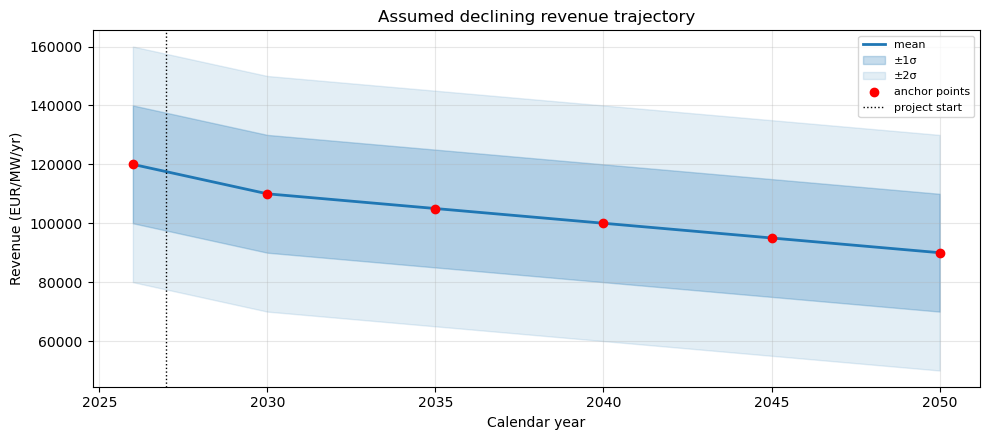

In [10]:
plot_years = np.arange(_anchor_years.min(), _anchor_years.max() + 1)
plot_means = np.array([revenue_mean_std(y)[0] for y in plot_years])
plot_stds  = np.array([revenue_mean_std(y)[1] for y in plot_years])

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(plot_years, plot_means, color="#1f77b4", lw=2, label="mean")
ax.fill_between(plot_years, plot_means - plot_stds, plot_means + plot_stds,
                 alpha=0.25, color="#1f77b4", label="±1σ")
ax.fill_between(plot_years, plot_means - 2*plot_stds, plot_means + 2*plot_stds,
                 alpha=0.12, color="#1f77b4", label="±2σ")
ax.scatter(_anchor_years, _anchor_means, color="red", zorder=5, label="anchor points")
ax.axvline(PROJECT_START_YEAR, color="black", ls=":", lw=1, label="project start")
ax.set_xlabel("Calendar year")
ax.set_ylabel("Revenue (EUR/MW/yr)")
ax.set_title("Assumed declining revenue trajectory")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 2. Visualise input distributions

Each panel shows the truncated-normal PDF implied by the mean/std/bounds above.

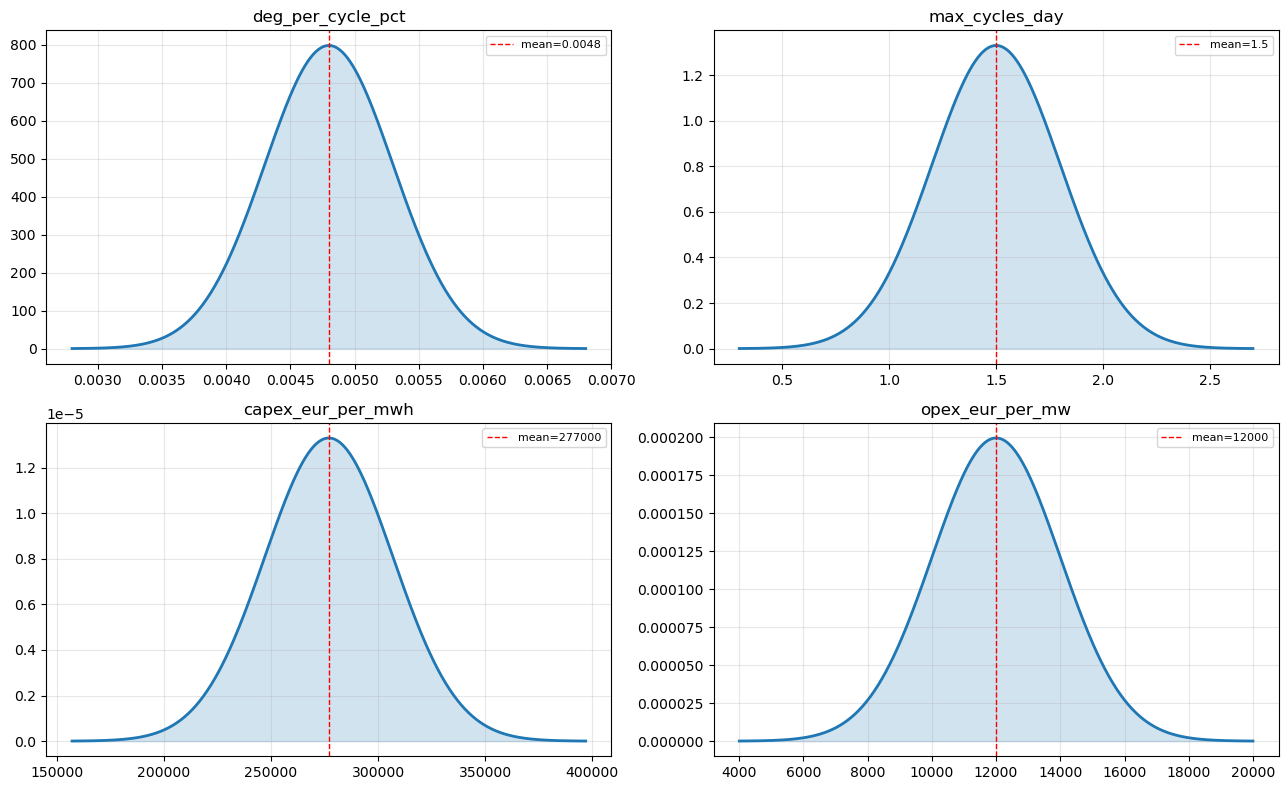

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.ravel()

for ax, (name, p) in zip(axes, STOCHASTIC_INPUTS.items()):
    mean, std, low, high = p["mean"], p["std"], p["low"], p["high"]
    a, b = (low - mean) / std, (high - mean) / std
    x_lo = max(low, mean - 4 * std)
    x_hi = min(high, mean + 4 * std) if np.isfinite(high) else mean + 4 * std
    x = np.linspace(x_lo, x_hi, 400)
    y = truncnorm.pdf(x, a, b, loc=mean, scale=std)
    ax.plot(x, y, color="#1f77b4", lw=2)
    ax.fill_between(x, y, alpha=0.2, color="#1f77b4")
    ax.axvline(mean, color="red", ls="--", lw=1, label=f"mean={mean:g}")
    ax.set_title(name)
    ax.legend(fontsize=8)

# hide unused subplots, if any
for ax in axes[len(STOCHASTIC_INPUTS):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 3. Monte Carlo simulation engine

For each simulation:
- Draw all stochastic project parameters once (these define the "scenario").
- Step year by year: degrade SoH by `cycles_per_year × degradation_per_cycle`, look up that
  operating year's **calendar year** on the revenue curve (`PROJECT_START_YEAR + year - 1`),
  draw a revenue rate from that year's mean/std, scale by `SoH / 100`, subtract OPEX.
- The project retires once SoH reaches the deterministic `SOH_CUTOFF_PCT` (60%) — operating life is
  therefore an **output** of the simulation, not an input. A `MAX_YEARS_SAFETY_CAP` stops the loop
  in the (essentially impossible) case degradation per cycle is sampled near zero.
- CAPEX (EUR/MWh × MWh) is paid as a single outflow in year 0.

In [12]:
MAX_YEARS_SAFETY_CAP = 60  # hard stop so a near-zero degradation draw can't loop forever

def run_simulation(n_sims, mw, mwh, discount_rate, stochastic_inputs, soh_cutoff_pct,
                    project_start_year, anchor_years, anchor_means, anchor_stds, rng):
    p = stochastic_inputs

    deg_cycle   = sample_truncnorm(size=n_sims, rng=rng, **p["deg_per_cycle_pct"])
    cycles_day  = sample_truncnorm(size=n_sims, rng=rng, **p["max_cycles_day"])
    capex_mwh   = sample_truncnorm(size=n_sims, rng=rng, **p["capex_eur_per_mwh"])
    opex_mw     = sample_truncnorm(size=n_sims, rng=rng, **p["opex_eur_per_mw"])

    npvs = np.empty(n_sims)
    irrs = np.full(n_sims, np.nan)
    actual_life = np.empty(n_sims)
    all_cashflows = []  # kept for inspection of a few sample paths

    for i in range(n_sims):
        capex = capex_mwh[i] * mwh
        cashflows = [-capex]
        soh = 100.0
        cycles_per_year = cycles_day[i] * 365.0
        year = 0

        while soh > soh_cutoff_pct and year < MAX_YEARS_SAFETY_CAP:
            year += 1
            soh = max(soh - cycles_per_year * deg_cycle[i], 0.0)

            # Look up that calendar year's revenue distribution (declining curve)
            calendar_year = project_start_year + year - 1
            rev_mean = np.interp(calendar_year, anchor_years, anchor_means)
            rev_std  = np.interp(calendar_year, anchor_years, anchor_stds)
            yearly_revenue_rate = sample_truncnorm(size=1, rng=rng,
                                                     mean=rev_mean, std=rev_std,
                                                     low=0, high=np.inf)[0]
            revenue = yearly_revenue_rate * mw * (soh / 100.0)
            opex = opex_mw[i] * mw
            cashflows.append(revenue - opex)
            if soh <= soh_cutoff_pct:
                break

        actual_life[i] = year
        npvs[i] = npf.npv(discount_rate, cashflows)
        try:
            irrs[i] = npf.irr(cashflows)
        except Exception:
            irrs[i] = np.nan

        if i < 5:
            all_cashflows.append(cashflows)

    return {
        "npv": npvs, "irr": irrs, "life": actual_life,
        "sample_cashflows": all_cashflows,
        "draws": dict(deg_cycle=deg_cycle, cycles_day=cycles_day,
                       capex_mwh=capex_mwh, opex_mw=opex_mw),
    }

results = run_simulation(N_SIMULATIONS, MW, MWH, DISCOUNT_RATE, STOCHASTIC_INPUTS, SOH_CUTOFF_PCT,
                           PROJECT_START_YEAR, _anchor_years, _anchor_means, _anchor_stds, rng)
print(f"Completed {N_SIMULATIONS:,} simulations.")
print(f"Simulations hitting the {MAX_YEARS_SAFETY_CAP}-year safety cap (degradation ~0): "
      f"{np.mean(results['life'] >= MAX_YEARS_SAFETY_CAP):.1%}")
print(f"Valid IRR solved for {np.mean(~np.isnan(results['irr'])):.1%} of runs.")

Completed 10,000 simulations.
Simulations hitting the 60-year safety cap (degradation ~0): 0.0%
Valid IRR solved for 100.0% of runs.


## 4. Cash flow distribution: NPV and IRR histograms

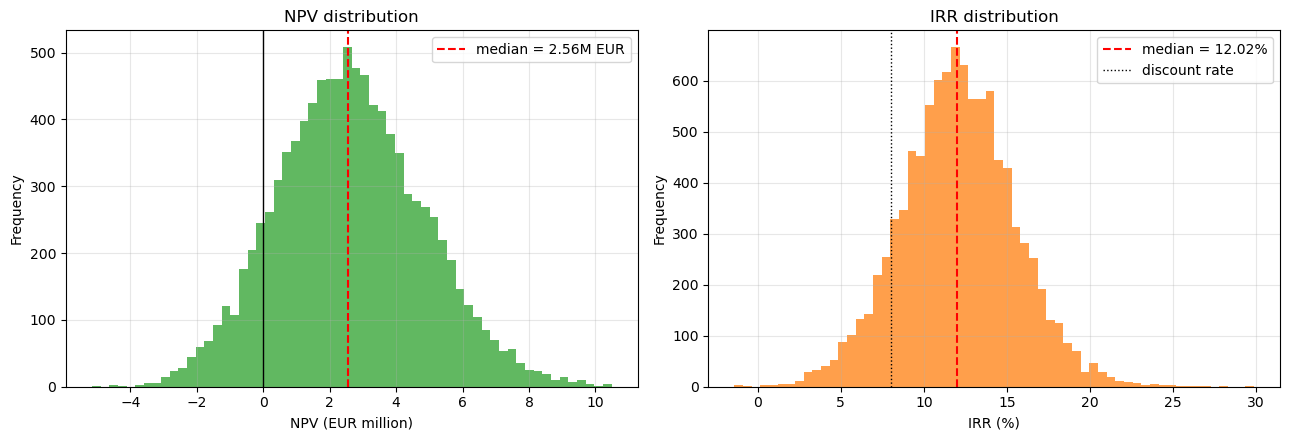

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(results["npv"] / 1e6, bins=60, color="#2ca02c", alpha=0.75)
axes[0].axvline(np.median(results["npv"]) / 1e6, color="red", ls="--",
                 label=f"median = {np.median(results['npv'])/1e6:,.2f}M EUR")
axes[0].axvline(0, color="black", lw=1)
axes[0].set_xlabel("NPV (EUR million)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("NPV distribution")
axes[0].legend()

irr_valid = results["irr"][~np.isnan(results["irr"])]
axes[1].hist(irr_valid * 100, bins=60, color="#ff7f0e", alpha=0.75)
axes[1].axvline(np.median(irr_valid) * 100, color="red", ls="--",
                 label=f"median = {np.median(irr_valid)*100:,.2f}%")
axes[1].axvline(DISCOUNT_RATE * 100, color="black", lw=1, ls=":", label="discount rate")
axes[1].set_xlabel("IRR (%)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("IRR distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Exceedance probability curve

Reads as: *"there is an X% probability that NPV/IRR **exceeds** this value."*
Left = conservative/downside (high exceedance probability = P95); right = optimistic/upside (low
exceedance probability = P5). Vertical markers show P95, P75, P50, P25, P05.
The intersection with the NPV = 0 line gives the probability of a **profitable** project.

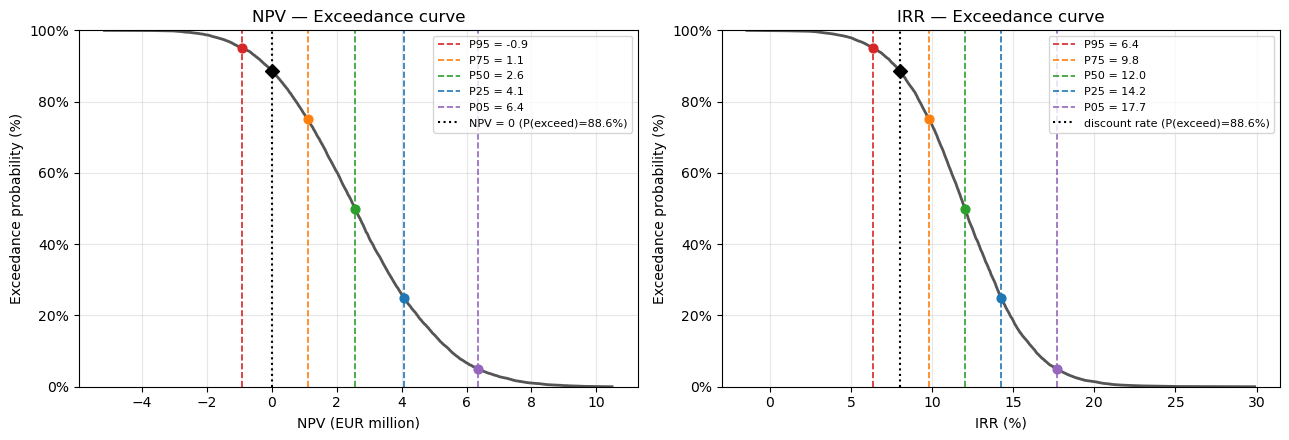

In [14]:
EXCEEDANCE_LEVELS = [95, 75, 50, 25, 5]
LEVEL_COLORS      = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4", "#9467bd"]  # red→purple

def plot_exceedance(ax, data, xlabel, vline=None, vline_label=None):
    data_sorted = np.sort(data)
    # Exceedance = 1 - CDF: probability of exceeding each value
    exceedance = 1 - np.arange(1, len(data_sorted) + 1) / len(data_sorted)
    ax.plot(data_sorted, exceedance * 100, color="#555555", lw=2)

    # P-level markers
    for lvl, col in zip(EXCEEDANCE_LEVELS, LEVEL_COLORS):
        val = np.percentile(data, 100 - lvl)          # exceedance Pxx = stat (100-xx)th pct
        ax.axvline(val, color=col, ls="--", lw=1.2, label=f"P{lvl:02d} = {val:,.1f}")
        ax.scatter([val], [lvl], color=col, zorder=5, s=40)

    if vline is not None:
        prob_exceed = np.mean(data > vline) * 100
        ax.axvline(vline, color="black", lw=1.5, ls=":", label=f"{vline_label} (P(exceed)={prob_exceed:.1f}%)")
        ax.scatter([vline], [prob_exceed], color="black", zorder=6, s=50, marker="D")

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Exceedance probability (%)")
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
    ax.legend(fontsize=8, loc="upper right")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_exceedance(axes[0], results["npv"] / 1e6, "NPV (EUR million)", vline=0, vline_label="NPV = 0")
axes[0].set_title("NPV — Exceedance curve")

plot_exceedance(axes[1], irr_valid * 100, "IRR (%)", vline=DISCOUNT_RATE * 100, vline_label="discount rate")
axes[1].set_title("IRR — Exceedance curve")

plt.tight_layout()
plt.show()

## 6. Summary statistics

**Percentile convention: exceedance probability** — P95 is the conservative/downside value
(only 5% of simulations did worse), P5 is the optimistic/upside value (only 5% of simulations did
better). Table runs P95 → P5, i.e. worst-to-best, left to right within each block.

| Label | Meaning | Statistical percentile |
|---|---|---|
| P95 | Conservative / downside case | 5th |
| P75 | Lower-mid case | 25th |
| P50 | Median | 50th |
| P25 | Upper-mid case | 75th |
| P05 | Optimistic / upside case | 95th |

In [15]:
def exceedance_percentiles(data, levels=(95, 75, 50, 25, 5)):
    """Return a dict of P{level} -> value, using exceedance-probability convention:
    Pxx = the value exceeded with probability xx% = statistical (100 - xx)th percentile.
    Ordered P95 (conservative) -> P05 (optimistic)."""
    data = np.asarray(data)
    return {f"P{lvl:02d}": np.percentile(data, 100 - lvl) for lvl in levels}

def build_summary(data, label):
    base = pd.Series(data).agg(["count", "mean", "std", "min", "max"])
    pcts = pd.Series(exceedance_percentiles(data))
    # P95 (downside) first, P05 (upside) last
    ordered = pd.concat([base[["count", "mean", "std", "min"]],
                          pcts[["P95", "P75", "P50", "P25", "P05"]],
                          base[["max"]]])
    ordered.name = label
    return ordered

summary = pd.concat([
    build_summary(results["npv"], "NPV (EUR)"),
    build_summary(irr_valid * 100, "IRR (%)"),
    build_summary(results["life"], "Project life (yrs)"),
], axis=1)

print(f"P(NPV > 0) [= P05 upside share]: {np.mean(results['npv'] > 0):.1%}")
print(f"P(IRR > discount rate)         : {np.mean(irr_valid > DISCOUNT_RATE):.1%}")
print(f"Simulations with no real IRR solution: {np.mean(np.isnan(results['irr'])):.1%}")
print()
summary.round(2)

P(NPV > 0) [= P05 upside share]: 88.6%
P(IRR > discount rate)         : 88.6%
Simulations with no real IRR solution: 0.0%



,NPV (EUR),IRR (%),Project life (yrs)
count,10000.00,10000.00,10000.00
mean,2628324.77,12.05,16.59
std,2204770.56,3.44,4.24
min,-5159456.01,-1.41,8.00
P95,-920755.75,6.38,11.00
P75,1105491.93,9.83,14.00
P50,2562072.33,12.02,16.00
P25,4072800.56,14.24,19.00
P05,6363641.31,17.70,24.00
max,10484414.44,29.88,60.00


## Notes / next steps

- **Operating life** is now purely an output: each simulation runs until SoH hits the deterministic
  `SOH_CUTOFF_PCT` (60%). If different projects in your portfolio actually use different contractual
  cut-offs (e.g. warranty-driven 60% vs 70%), that's an easy re-add as a scenario-level input rather
  than a per-simulation random draw.
- **Revenue** now follows a declining calendar-year curve (`REVENUE_ANCHORS`) rather than a flat
  distribution — edit the anchor points to match your own price/cannibalisation view (e.g. derived
  from your German DA price work, or pulled via the Modo Energy connector). Years beyond 2050
  (or before 2026) hold flat at the nearest anchor — extend the anchor list if you want the decline
  (or a rebound) to continue further out.
- **CAPEX/OPEX correlation**: currently independent draws. If in reality higher CAPEX projects also
  tend toward lower OPEX (or vice versa), a correlated joint sampling (e.g. via a copula or
  `np.random.multivariate_normal` then truncating) would be more realistic.
- **Tax & financing** are excluded (unlevered, pre-tax) per the current scope — flag if you want a
  levered/post-tax version added as a second layer on top of this engine.
- **Degradation** is purely cycle-based; calendar/age-based fade isn't modelled separately — let me
  know if you want both effects layered.
